# Terzaghi 1D Single-Layer Verification Notebook

This notebook compares the 1D single-layer FEM solver against the analytical Fourier-series solution for the standard uniform initial excess pore-pressure case.

The main checks are:

1. pore-pressure agreement between FEM and analytical solution
2. settlement-history agreement
3. mesh-refinement behaviour
4. time-step refinement behaviour

This notebook is intended as the main numerical verification notebook for the single-layer uniform case.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2
import os
import sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terzaghi_1d.fem import Get_terzaghi1D_FEA
from src.geotech_consolidation.models.terzaghi_1d.analytical import Get_terzaghi1d_Analytical

sns.set_theme(style="whitegrid")

H = 5.0
num = 50
nodes = num + 1
load = 100.0
Cv = 2e-7
Mv = 5e-4
T = 365 * 24 * 60 * 60
time_steps = 1000
N_terms = 200

depth = np.linspace(0.0, H, nodes)
time_days = np.linspace(0.0, T / (60 * 60 * 24), time_steps)
total_settlement = Mv * load * H

## FEM and Analytical Solutions

The FEM model is solved first, followed by the analytical Fourier-series reference solution on the same depth and time grids.

In [ ]:
fem_settlement_hist, fem_udata, fem_settlement_profile = Get_terzaghi1D_FEA(
    H, num, load, T, time_steps, Cv, 0.0, Mv, True
)

analytical_cdata, analytical_udata, depth_a, time_a = Get_terzaghi1d_Analytical(
    H, num, load, T, time_steps, Cv, N_terms
)

fem_frame = pd.DataFrame(fem_udata, columns=-depth, index=time_days)
analytical_frame = pd.DataFrame(analytical_udata, columns=-depth_a, index=time_a)

print(f"FEM pore-pressure array:        {fem_udata.shape}")
print(f"Analytical pore-pressure array: {analytical_udata.shape}")
print(f"Total theoretical settlement:   {total_settlement:.6f} m")

## Pore-Pressure Error Through Time

Errors are computed directly from the difference between FEM and analytical excess pore pressure at each time step.

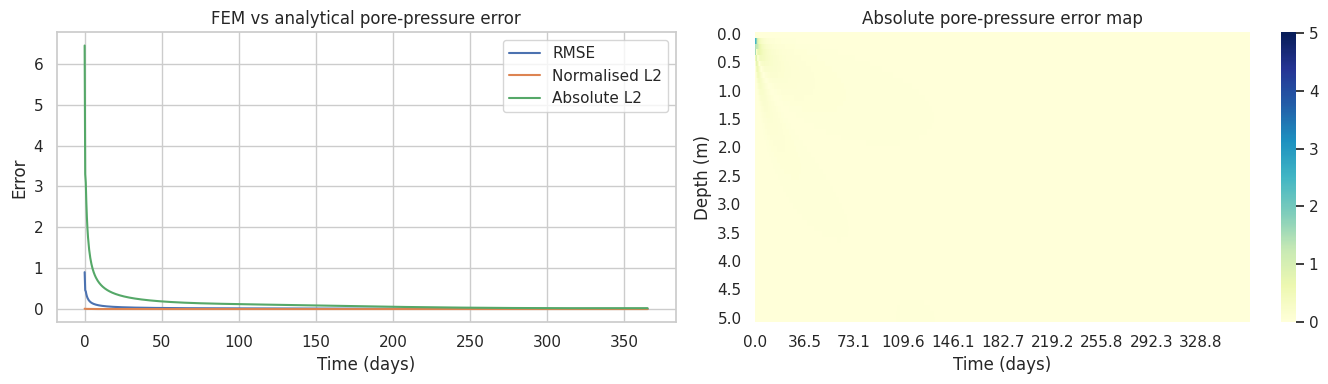

In [ ]:
error = fem_udata - analytical_udata
rmse = np.sqrt((error**2).mean(axis=1))
num_l2 = (error**2).sum(axis=1)
den_l2 = (analytical_udata**2).sum(axis=1)
norm_l2 = np.sqrt(num_l2 / (den_l2 + 1e-12))
abs_l2 = np.sqrt(num_l2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(time_days, rmse, label="RMSE")
axes[0].plot(time_days, norm_l2, label="Normalised L2")
axes[0].plot(time_days, abs_l2, label="Absolute L2")
axes[0].set_xlabel("Time (days)")
axes[0].set_ylabel("Error")
axes[0].set_title("FEM vs analytical pore-pressure error")
axes[0].legend()

kx = max(1, len(time_days) // 10)
ky = max(1, len(depth) // 10)
heat = sns.heatmap(
    np.abs(error).T,
    annot=False,
    cmap="YlGnBu",
    xticklabels=time_days,
    yticklabels=depth,
    ax=axes[1],
)
axes[1].set_xticks(np.arange(0, len(time_days), kx) + 0.5)
axes[1].set_xticklabels([f"{time_days[i]:.1f}" for i in range(0, len(time_days), kx)], rotation=0)
axes[1].set_yticks(np.arange(0, len(depth), ky) + 0.5)
axes[1].set_yticklabels([f"{depth[i]:.1f}" for i in range(0, len(depth), ky)], rotation=0)
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Depth (m)")
axes[1].set_title("Absolute pore-pressure error map")

plt.tight_layout()
plt.show()

## Settlement Comparison

The analytical average degree of consolidation is converted to settlement using `s = U_avg Mv load H` and then compared against the FEM settlement history.

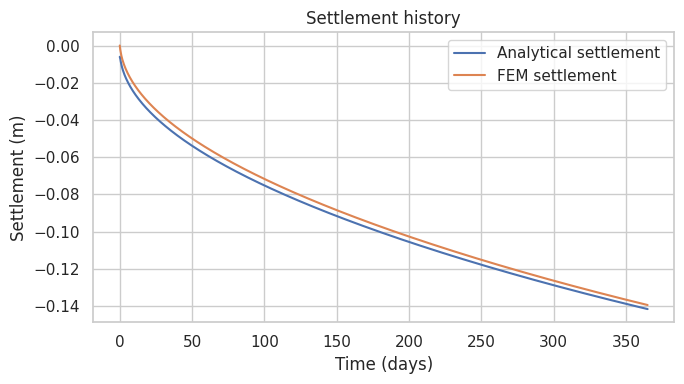

,quantity,settlement_m
0,Analytical final,0.141650
1,FEM final,0.139476
2,Theoretical total,0.250000


In [ ]:
analytical_settlement = analytical_cdata.mean(axis=1) * total_settlement

plt.figure(figsize=(7, 4))
plt.plot(time_days, -analytical_settlement, label="Analytical settlement")
plt.plot(time_days, -fem_settlement_hist, label="FEM settlement")
plt.xlabel("Time (days)")
plt.ylabel("Settlement (m)")
plt.title("Settlement history")
plt.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(
    {
        "quantity": ["Analytical final", "FEM final", "Theoretical total"],
        "settlement_m": [analytical_settlement[-1], fem_settlement_hist[-1], total_settlement],
    }
)

## Mesh and Time-Step Convergence

For both studies, the error is taken at the final time step so that the early-time boundary-layer mismatch does not dominate the trend.

In [ ]:
mesh_sizes = np.array([5, 10, 20, 40, 80], dtype=int)
T_conv = 50 * 24 * 60 * 60
time_steps_conv = 5000
N_terms_conv = 400

mesh_h = H / mesh_sizes
mesh_l2 = []

for nx in mesh_sizes:
    _, fem_u, _ = Get_terzaghi1D_FEA(H, nx, load, T_conv, time_steps_conv, Cv, 0.0, Mv, True)
    _, analytical_u, _, _ = Get_terzaghi1d_Analytical(H, nx, load, T_conv, time_steps_conv, Cv, N_terms_conv)
    err_final = fem_u[-1, :] - analytical_u[-1, :]
    dz = H / (len(err_final) - 1)
    abs_l2_final = np.sqrt(np.sum(err_final**2) * dz)
    ref_l2 = np.sqrt(np.sum(analytical_u[0, :]**2) * dz)
    mesh_l2.append(abs_l2_final / (ref_l2 + 1e-30))

mesh_l2 = np.asarray(mesh_l2)
p_mesh, logC_mesh = np.polyfit(np.log(mesh_h), np.log(mesh_l2), 1)
fit_mesh = np.exp(logC_mesh) * mesh_h**p_mesh

plt.figure(figsize=(6, 4))
plt.loglog(mesh_h, mesh_l2, "o", label="Measured")
plt.loglog(mesh_h, fit_mesh, "--", label=f"Fit slope = {p_mesh:.3f}")
plt.xlabel("Mesh size, h")
plt.ylabel("Final-time normalised L2 error")
plt.title("Mesh convergence")
plt.legend()
plt.tight_layout()
plt.show()

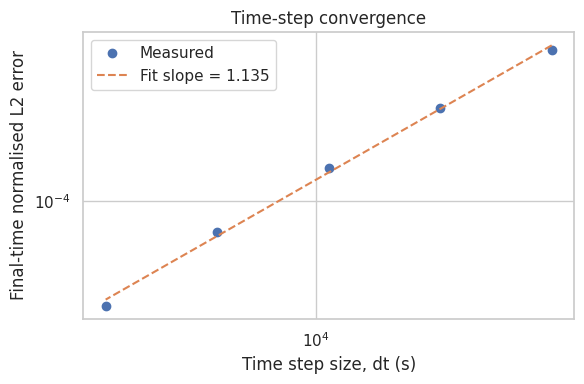

In [ ]:
num_fixed = 200
time_steps_list = np.array([100, 200, 400, 800, 1600], dtype=int)
dt_list = T_conv / time_steps_list
time_l2 = []

for n_steps in time_steps_list:
    _, fem_u, _ = Get_terzaghi1D_FEA(H, num_fixed, load, T_conv, n_steps, Cv, 0.0, Mv, True)
    _, analytical_u, _, _ = Get_terzaghi1d_Analytical(H, num_fixed, load, T_conv, n_steps, Cv, N_terms_conv)
    err_final = fem_u[-1, :] - analytical_u[-1, :]
    dz = H / (len(err_final) - 1)
    abs_l2_final = np.sqrt(np.sum(err_final**2) * dz)
    ref_l2 = np.sqrt(np.sum(analytical_u[0, :]**2) * dz)
    time_l2.append(abs_l2_final / (ref_l2 + 1e-30))

time_l2 = np.asarray(time_l2)
p_time, logC_time = np.polyfit(np.log(dt_list), np.log(time_l2), 1)
fit_time = np.exp(logC_time) * dt_list**p_time

plt.figure(figsize=(6, 4))
plt.loglog(dt_list, time_l2, "o", label="Measured")
plt.loglog(dt_list, fit_time, "--", label=f"Fit slope = {p_time:.3f}")
plt.xlabel("Time step size, dt (s)")
plt.ylabel("Final-time normalised L2 error")
plt.title("Time-step convergence")
plt.legend()
plt.tight_layout()
plt.show()

## Short Note on Total Settlement and Quadrature

For the single-layer case, total settlement follows from the strain integral

`s(t) = integral_0^H Mv [u0(z) - u(z, t)] dz`

In discrete form, that integral must be approximated numerically. Two common options are:

- rectangle-rule style summation: `sum(strain * dz)`
- trapezoidal integration: `trapz(strain, z)`

That quadrature choice should be stated explicitly in the dissertation, because the reported settlement can change slightly even when the pore-pressure field is unchanged.